In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import anndata as ad
import logging
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
import seaborn as sns
import sys
from matplotlib.lines import Line2D
from sccnasim.utils.gcna import load_cnas

In [3]:
utils_dir = "/groups/cgsd/xianjie/projects/cna-benchmark/HCC3N_600spot/simulator_evaluation/rs_benchmark/baf/snp/base/scripts"
sys.path.append(utils_dir)
from ubaf import *
from ubase import *

In [4]:
cna_fn = '/groups/cgsd/xianjie/projects/cna-benchmark/HCC3N_600spot/simulator_evaluation/base/data/cna_profile.tsv'
in_dir = '/groups/cgsd/xianjie/projects/cna-benchmark/HCC3N_600spot/simulator_evaluation/rs_benchmark/baf/snp/base/pp'
out_dir = '/groups/cgsd/xianjie/projects/cna-benchmark/HCC3N_600spot/simulator_evaluation/rs_benchmark/baf/snp/pseudobulk'
chrom_anno_fn = '/groups/cgsd/xianjie/projects/cna-benchmark/HCC3N_600spot/simulator_evaluation/rs_benchmark/baf/gene/pseudobulk/data/chrom_arm_length.3col.tsv'

In [5]:
min_DP = 10
min_AF = 0.1
max_AF = 0.9

In [6]:
blue = '#0072B2'
orange = '#E69F00'
green = '#009E73'
red = '#D55E00'     # Vermillion

def_color = blue

In [7]:
cw_prefix = 'cw-'
sw_prefix = 'sw-'

dpi = 300

In [8]:
tool_labels = ['seed_N', 'stCNASim-rs_N', 'scReadSim-cna_N', 'stCNASim-rs_T', 'scReadSim-cna_T']

# Prepare Data

## Generate annotation of SNP CNA type

In [9]:
os.makedirs(out_dir, exist_ok = True)

In [10]:
cna = load_cnas(cna_fn)
cna

,chrom,start,end,clone,cn_ale0,cn_ale1,region
0,1,123400001,248956422,tumor,1,2,1:123400001-248956422
1,4,50000001,190214555,tumor,0,1,4:50000001-190214555
2,8,1,45200000,tumor,0,1,8:1-45200000
3,8,45200001,145138636,tumor,1,2,8:45200001-145138636
4,13,17700001,114364328,tumor,2,0,13:17700001-114364328
5,17,1,25100000,tumor,2,0,17:1-25100000


In [11]:
adata = ad.read_h5ad(os.path.join(in_dir, "rs_normal.h5ad"))
adata

AnnData object with n_obs × n_vars = 600 × 8866
    obs: 'cell', 'cell_type'
    var: 'CHROM', 'POS', 'ID', 'REF', 'ALT', 'QUAL', 'FILTER', 'INFO', 'chrom', 'start', 'end', 'snp', 'hap0', 'hap1', 'feature'
    layers: 'AD', 'AD_pre_phase', 'DP', 'OTH'

In [12]:
snp_anno = adata.var.copy()
snp_anno['snp'] = snp_anno['feature']
snp_anno['snp_cna_type'] = 'N.A.'
snp_anno

,CHROM,POS,ID,REF,ALT,QUAL,FILTER,INFO,chrom,start,end,snp,hap0,hap1,feature,snp_cna_type
feature,,,,,,,,,,,,,,,,
1:840279,chr1,840279,.,A,G,.,PASS,AD=0;DP=0;OTH=0,1,840279,840279,1:840279,1,0,1:840279,N.A.
1:996128,chr1,996128,.,T,A,.,PASS,AD=9;DP=9;OTH=0,1,996128,996128,1:996128,1,0,1:996128,N.A.
1:1217251,chr1,1217251,.,C,A,.,PASS,AD=83;DP=180;OTH=0,1,1217251,1217251,1:1217251,0,1,1:1217251,N.A.
1:1468636,chr1,1468636,.,G,A,.,PASS,AD=0;DP=3;OTH=0,1,1468636,1468636,1:1468636,0,1,1:1468636,N.A.
1:1719368,chr1,1719368,.,T,C,.,PASS,AD=4;DP=8;OTH=0,1,1719368,1719368,1:1719368,1,0,1:1719368,N.A.
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9:136862025,chr9,136862025,.,G,A,.,PASS,AD=0;DP=0;OTH=0,9,136862025,136862025,9:136862025,0,1,9:136862025,N.A.
9:136954236,chr9,136954236,.,C,T,.,PASS,AD=0;DP=9;OTH=0,9,136954236,136954236,9:136954236,0,1,9:136954236,N.A.
9:137273425,chr9,137273425,.,T,G,.,PASS,AD=109;DP=163;OTH=0,9,137273425,137273425,9:137273425,1,0,9:137273425,N.A.


In [13]:
def is_cna_feature(x, df):
    chrom, start, end = x["chrom"], x["start"], x["end"]
    d = df[(df["chrom"] == chrom) & (df["start"] <= end) & (df["end"] >= start)]
    return(d.shape[0] > 0)

In [14]:
# Neutral snps
bool_is_cna = adata.var.apply(is_cna_feature, axis = 1, df = cna)
cna_snps = adata.var["feature"][bool_is_cna].to_numpy()
print(cna_snps.shape)

snp_anno.loc[~(snp_anno['snp'].isin(cna_snps)), 'snp_cna_type'] = 'Neutral'
snp_anno['snp_cna_type'].value_counts()

(1485,)


snp_cna_type
Neutral    7381
N.A.       1485
Name: count, dtype: int64

In [15]:
# Gain snps
df_cna = cna.loc[cna['cn_ale0'] + cna['cn_ale1'] > 2].copy()
bool_is_cna = adata.var.apply(is_cna_feature, axis = 1, df = df_cna)
cna_snps = adata.var["feature"][bool_is_cna].to_numpy()
print(cna_snps.shape)

assert np.all(snp_anno.loc[snp_anno['snp'].isin(cna_snps), 'snp_cna_type'] == 'N.A.')
snp_anno.loc[snp_anno['snp'].isin(cna_snps), 'snp_cna_type'] = 'Gain'
snp_anno['snp_cna_type'].value_counts()

(611,)


snp_cna_type
Neutral    7381
N.A.        874
Gain        611
Name: count, dtype: int64

In [16]:
# Loss snps
df_cna = cna.loc[cna['cn_ale0'] + cna['cn_ale1'] < 2].copy()
bool_is_cna = adata.var.apply(is_cna_feature, axis = 1, df = df_cna)
cna_snps = adata.var["feature"][bool_is_cna].to_numpy()
print(cna_snps.shape)

assert np.all(snp_anno.loc[snp_anno['snp'].isin(cna_snps), 'snp_cna_type'] == 'N.A.')
snp_anno.loc[snp_anno['snp'].isin(cna_snps), 'snp_cna_type'] = 'Loss'
snp_anno['snp_cna_type'].value_counts()

(459,)


snp_cna_type
Neutral    7381
Gain        611
Loss        459
N.A.        415
Name: count, dtype: int64

In [17]:
# LOH snps
df_cna = cna.loc[cna['cn_ale0'] + cna['cn_ale1'] == 2].copy()
bool_is_cna = adata.var.apply(is_cna_feature, axis = 1, df = df_cna)
cna_snps = adata.var["feature"][bool_is_cna].to_numpy()
print(cna_snps.shape)

assert np.all(snp_anno.loc[snp_anno['snp'].isin(cna_snps), 'snp_cna_type'] == 'N.A.')
snp_anno.loc[snp_anno['snp'].isin(cna_snps), 'snp_cna_type'] = 'LOH'
snp_anno['snp_cna_type'].value_counts()

(415,)


snp_cna_type
Neutral    7381
Gain        611
Loss        459
LOH         415
Name: count, dtype: int64

## Load adata files

In [18]:
seed_normal_fn = os.path.join(in_dir, "seed_normal.h5ad")
rs_normal_fn = os.path.join(in_dir, "rs_normal.h5ad")
rs_tumor_fn = os.path.join(in_dir, "rs_tumor.h5ad")
scrs_normal_fn = os.path.join(in_dir, "scrs_normal.h5ad")
scrs_tumor_fn = os.path.join(in_dir, "scrs_tumor.h5ad")

In [19]:
seed_normal = ad.read_h5ad(seed_normal_fn)
print(seed_normal)

rs_normal = ad.read_h5ad(rs_normal_fn)
print(rs_normal)

rs_tumor = ad.read_h5ad(rs_tumor_fn)
print(rs_tumor)

scrs_normal = ad.read_h5ad(scrs_normal_fn)
print(scrs_normal)

scrs_tumor = ad.read_h5ad(scrs_tumor_fn)
print(scrs_tumor)

AnnData object with n_obs × n_vars = 600 × 8866
    obs: 'cell', 'cell_type'
    var: 'CHROM', 'POS', 'ID', 'REF', 'ALT', 'QUAL', 'FILTER', 'INFO', 'chrom', 'start', 'end', 'snp', 'hap0', 'hap1', 'feature'
    layers: 'AD', 'AD_pre_phase', 'DP', 'OTH'
AnnData object with n_obs × n_vars = 600 × 8866
    obs: 'cell', 'cell_type'
    var: 'CHROM', 'POS', 'ID', 'REF', 'ALT', 'QUAL', 'FILTER', 'INFO', 'chrom', 'start', 'end', 'snp', 'hap0', 'hap1', 'feature'
    layers: 'AD', 'AD_pre_phase', 'DP', 'OTH'
AnnData object with n_obs × n_vars = 600 × 8866
    obs: 'cell', 'cell_type'
    var: 'CHROM', 'POS', 'ID', 'REF', 'ALT', 'QUAL', 'FILTER', 'INFO', 'chrom', 'start', 'end', 'snp', 'hap0', 'hap1', 'feature'
    layers: 'AD', 'AD_pre_phase', 'DP', 'OTH'
AnnData object with n_obs × n_vars = 600 × 8866
    obs: 'cell', 'cell_type'
    var: 'CHROM', 'POS', 'ID', 'REF', 'ALT', 'QUAL', 'FILTER', 'INFO', 'chrom', 'start', 'end', 'snp', 'hap0', 'hap1', 'feature'
    layers: 'AD', 'AD_pre_phase', 'DP'

## Load chrom annotations

In [20]:
chrom_anno = pd.read_csv(chrom_anno_fn, sep = '\t')
chrom_anno

,chrom,q_arm_start,q_arm_end
0,1,123400000,248956422
1,2,93900000,242193529
2,3,90900000,198295559
3,4,50000000,190214555
4,5,48800000,181538259
5,6,59800000,170805979
6,7,60100000,159345973
7,8,45200000,145138636
8,9,43000000,138394717
9,10,39800000,133797422


# Get metrics

In [21]:
mv = get_snp_metrics_group(
    adata_lst = [seed_normal, rs_normal, scrs_normal, rs_tumor, scrs_tumor],
    X_names = tool_labels,
    id_lst = [seed_normal.var['feature'].to_numpy(), rs_normal.var['feature'].to_numpy(), scrs_normal.var['feature'].to_numpy(),
             rs_tumor.var['feature'].to_numpy(), scrs_tumor.var['feature'].to_numpy()],
    metrics = ["mean", "var", "cv", "zero_prop", "sum"]
)
mv = mv.rename(columns = dict(X_name = 'group'))
mv

,mean,var,cv,zero_prop,sum,group,feature,DP,AD,baf
0,0.000000,0.000000,0.000000,1.000000,0,seed_N,1:840279,0,0,NaN
1,0.010000,0.009900,9.949874,0.990000,6,seed_N,1:996128,6,0,0.000000
2,0.178333,0.166531,2.288308,0.831667,107,seed_N,1:1217251,107,51,0.476636
3,0.010000,0.009900,9.949874,0.990000,6,seed_N,1:1468636,6,2,0.333333
4,0.010000,0.013233,11.503623,0.991667,6,seed_N,1:1719368,6,2,0.333333
...,...,...,...,...,...,...,...,...,...,...
44325,0.000000,0.000000,0.000000,1.000000,0,scReadSim-cna_T,9:136862025,0,0,NaN
44326,0.011667,0.011531,9.204036,0.988333,7,scReadSim-cna_T,9:136954236,7,0,0.000000
44327,0.145000,0.140642,2.586360,0.863333,87,scReadSim-cna_T,9:137273425,87,87,1.000000
44328,0.016667,0.016389,7.681146,0.983333,10,scReadSim-cna_T,9:137273533,10,10,1.000000


In [22]:
tmp = mv[["group", "feature", "DP", "mean", "baf"]]

tmp.to_csv(
    os.path.join(out_dir, sw_prefix + "metric_values.tsv"), 
    header = True, 
    index = False, 
    sep = "\t"
)

# Filter snps

In [23]:
filter_snps = mv.loc[
    (mv['group'] == 'seed_N') & 
    (
        (mv['DP'] < min_DP) |
        (mv['baf'] < min_AF) | (mv['baf'] > max_AF)
    ),
    'feature'
]
print(filter_snps.shape)

df = mv.loc[~(mv['feature'].isin(filter_snps))].copy()
mv_DP, idx_DP = remove_nan_baf(df, how = 'independent')


tmp = mv_DP.copy()
tmp.to_csv(
    os.path.join(out_dir, sw_prefix + "metric_values-filter_nan-filter_DP.tsv"), 
    header = True, 
    index = False, 
    sep = "\t"
)

(7297,)


In [24]:
mv_DP['snp'] = mv_DP['feature']
df_baf = mv_DP[['group', 'snp', 'DP', 'baf']].merge(snp_anno, on = 'snp', how = 'left')
df_baf

,group,snp,DP,baf,CHROM,POS,ID,REF,ALT,QUAL,FILTER,INFO,chrom,start,end,hap0,hap1,feature,snp_cna_type
0,seed_N,1:1217251,107,0.476636,chr1,1217251,.,C,A,.,PASS,AD=83;DP=180;OTH=0,1,1217251,1217251,0,1,1:1217251,Neutral
1,seed_N,1:2189679,125,0.592000,chr1,2189679,.,C,T,.,PASS,AD=90;DP=227;OTH=0,1,2189679,2189679,1,0,1:2189679,Neutral
2,seed_N,1:9268027,13,0.153846,chr1,9268027,.,G,A,.,PASS,AD=2;DP=32;OTH=0,1,9268027,9268027,0,1,1:9268027,Neutral
3,seed_N,1:9367783,12,0.500000,chr1,9367783,.,A,G,.,PASS,AD=15;DP=23;OTH=0,1,9367783,9367783,1,0,1:9367783,Neutral
4,seed_N,1:9848424,19,0.631579,chr1,9848424,.,C,T,.,PASS,AD=14;DP=37;OTH=0,1,9848424,9848424,1,0,1:9848424,Neutral
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7816,scReadSim-cna_T,9:136673235,400,1.000000,chr9,136673235,.,G,A,.,PASS,AD=311;DP=655;OTH=0,9,136673235,136673235,1,0,9:136673235,Neutral
7817,scReadSim-cna_T,9:136723831,10,1.000000,chr9,136723831,.,A,G,.,PASS,AD=11;DP=24;OTH=0,9,136723831,136723831,1,0,9:136723831,Neutral
7818,scReadSim-cna_T,9:136724914,24,1.000000,chr9,136724914,.,C,G,.,PASS,AD=13;DP=30;OTH=0,9,136724914,136724914,1,0,9:136724914,Neutral
7819,scReadSim-cna_T,9:137273425,87,1.000000,chr9,137273425,.,T,G,.,PASS,AD=109;DP=163;OTH=0,9,137273425,137273425,1,0,9:137273425,Neutral


# Plot BAF signals

In [25]:
chr_info = {}
for i in range(chrom_anno.shape[0]):
    chr_info[str(chrom_anno['chrom'].iloc[i])] = (
        chrom_anno['q_arm_end'].iloc[i],
        chrom_anno['q_arm_start'].iloc[i]
    )
chr_info

{'1': (248956422, 123400000),
 '2': (242193529, 93900000),
 '3': (198295559, 90900000),
 '4': (190214555, 50000000),
 '5': (181538259, 48800000),
 '6': (170805979, 59800000),
 '7': (159345973, 60100000),
 '8': (145138636, 45200000),
 '9': (138394717, 43000000),
 '10': (133797422, 39800000),
 '11': (135086622, 53400000),
 '12': (133275309, 35500000),
 '13': (114364328, 17700000),
 '14': (107043718, 17200000),
 '15': (101991189, 19000000),
 '16': (90338345, 36800000),
 '17': (83257441, 25100000),
 '18': (80373285, 18500000),
 '19': (58617616, 26200000),
 '20': (64444167, 28100000),
 '21': (46709983, 12000000),
 '22': (50818468, 15000000)}

In [26]:
def plot_baf(df_baf, out_fn, figsize = (10, 1), dpi = 300):
    chr_list = list(chr_info.keys())
    x_total = 0
    chr_bounds = {}
    arm_bounds = []
    gap = 1e7      # otherwise, points could overlap bound lines.
    fontsize = 7

    for chr_num in chr_list:
        len_chr, cen_pos = chr_info[chr_num]
        p_start = x_total
        q_start = x_total + cen_pos + gap
        chr_end = x_total + len_chr + gap*2
        chr_bounds[chr_num] = (p_start, q_start, chr_end)
        arm_bounds.append(q_start)
        x_total = chr_end

    color_dict = {
        "Gain": "#D14050",
        "Loss": "#0078BB",
        "LOH": "#40B5A8",
        "Neutral": '#B3B3B3'
    }

    df = pd.DataFrame(data = {
        'chr': df_baf['chrom'].astype(str),
        'x': (df_baf['start'] + df_baf['end']) / 2.0,
        'baf': df_baf['baf'],
        'cnv_state': df_baf['snp_cna_type']
    })
    for chr_num in chr_list:
        df.loc[df['chr'] == chr_num, 'x'] += chr_bounds[chr_num][0] + gap

    # Plot
    fig, ax = plt.subplots(1, 1, figsize = figsize, dpi = dpi)

    ax.axhline(0.5, color = 'black', lw = 1, ls = '--', alpha = 0.7)
    for chr_num in chr_list:    # Chromosome and arm borders
        ax.axvline(chr_bounds[chr_num][0], color = "#bbbbbb", lw = 1.0, zorder = 0)
    for pos in arm_bounds:
        ax.axvline(pos, color = "#e0e0e0", lw = 0.5, ls = '--', zorder = 0)

    # Neutral snps
    pointsize = 3
    neu = df[df.cnv_state == "Neutral"]
    sns.scatterplot(
        data = neu, x = "x", y = "baf", 
        color = color_dict["Neutral"], s = pointsize, alpha = 0.9, 
        ax = ax, zorder = 1
    )
    # CNA snps
    for state in ["Gain", "Loss", "LOH"]:
        sub = df[df.cnv_state == state]
        sns.scatterplot(
            data = sub, x = "x", y = "baf", color = color_dict[state], 
            s = pointsize, alpha = 0.9, 
            ax = ax, zorder = 2
        )
    # Median line.
    for chr_num in chr_list:
        sub = df.loc[(df.chr == chr_num) & (df.x < chr_bounds[chr_num][1])].sort_values("x")
        ax.hlines(sub.baf.median(), xmin = sub.x.min(), xmax = sub.x.max(), color = "#8B0000", lw = 0.8, zorder = 3)
        sub = df.loc[(df.chr == chr_num) & (df.x >= chr_bounds[chr_num][1])].sort_values("x")
        ax.hlines(sub.baf.median(), xmin = sub.x.min(), xmax = sub.x.max(), color = "#8B0000", lw = 0.8, zorder = 3)

    markersize = fontsize - 1.5
    legend_elements = [
        Line2D([0],[0], marker = 'o', color = 'w', markerfacecolor = color_dict["Gain"], 
               markersize = markersize, label = 'Gain'),
        Line2D([0],[0], marker = 'o', color = 'w', markerfacecolor = color_dict["Loss"], 
               markersize = markersize, label = 'Loss'),
        Line2D([0],[0], marker = 'o', color = 'w', markerfacecolor = color_dict["LOH"], 
               markersize = markersize, label = 'LOH'),
        Line2D([0],[0], marker = 'o', color = 'w', markerfacecolor = color_dict["Neutral"], 
               markersize = markersize, label = 'Neutral')
    ]
    fig.legend(
        handles = legend_elements, loc = "center left", bbox_to_anchor = (0.975, 0.5), 
        frameon = False, fontsize = fontsize, handletextpad = 0.1)

    for ax in [ax]:
        ax.spines['top'].set_visible(True)
        ax.spines['right'].set_visible(True)

    ax.set_xlabel(None)
    ax.set_ylabel(r"Phased AF", fontsize = fontsize)
    ax.set_xticks([(v[0]+v[2])/2 for v in chr_bounds.values()])
    ax.set_xticklabels([str(c) for c in chr_list], fontsize = fontsize)
    ax.tick_params(axis = 'x', length = 0)
    ax.set_xlim(0, chr_bounds['22'][-1])
    ax.set_yticks([0, 0.25, 0.5, 0.75, 1])
    ax.set_yticklabels(
        ax.get_yticklabels(), 
        fontsize = fontsize - 1
    )

    plt.tight_layout()
    fig.savefig(out_fn, dpi = dpi, bbox_inches = 'tight')

(1569, 19)


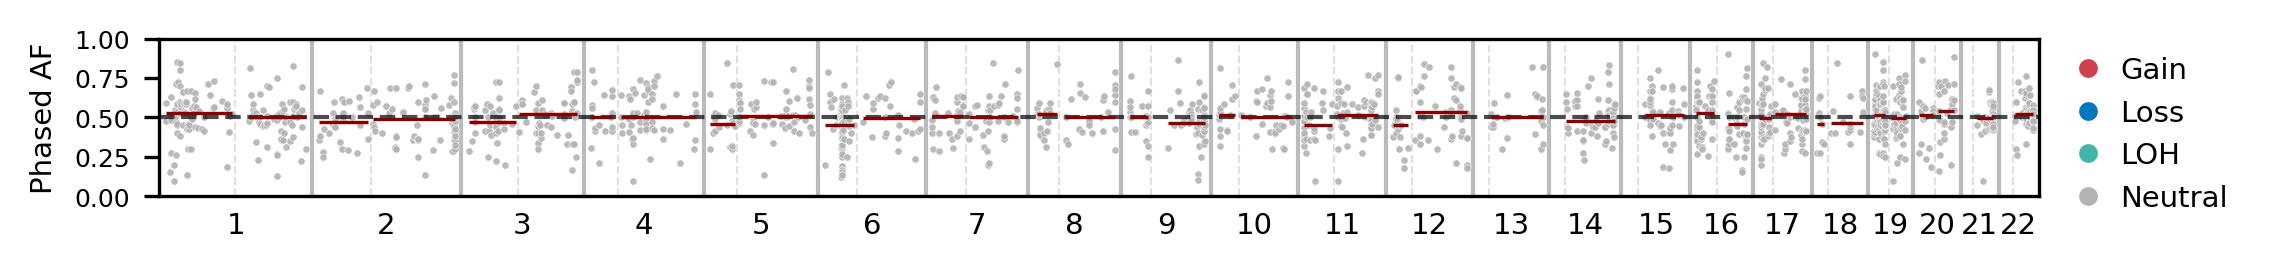

In [27]:
df = df_baf.loc[df_baf['group'] == 'seed_N'].copy()
print(df.shape)
df['snp_cna_type'] = 'Neutral'
fn = os.path.join(out_dir, sw_prefix + "baf-seed_N.png")
plot_baf(df, out_fn = fn, figsize = (7, 1))

(1568, 19)


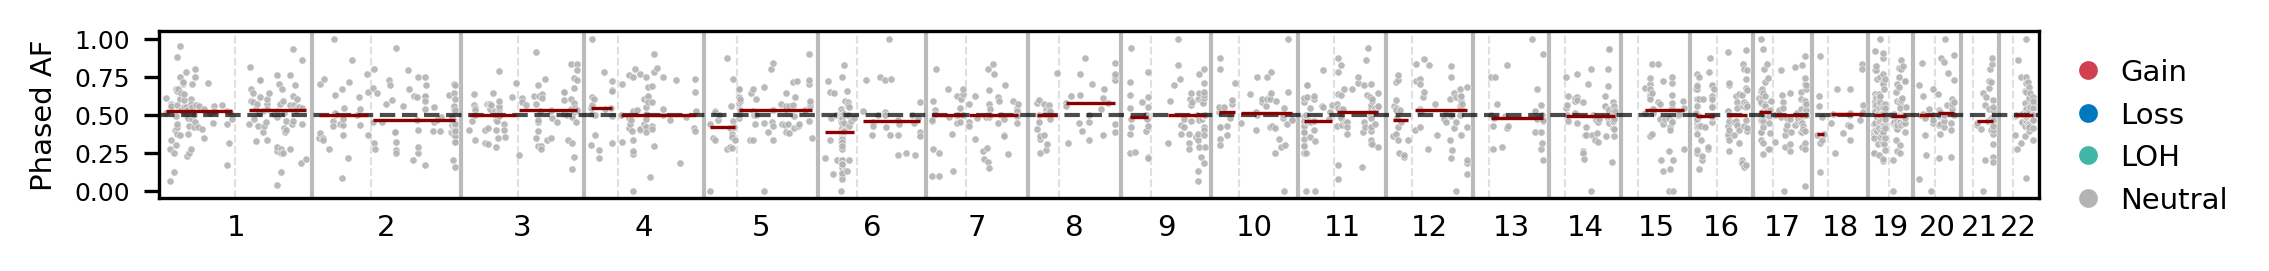

In [28]:
df = df_baf.loc[df_baf['group'] == 'stCNASim-rs_N'].copy()
print(df.shape)
df['snp_cna_type'] = 'Neutral'
fn = os.path.join(out_dir, sw_prefix + "baf-stCNASim-rs_N.png")
plot_baf(df, out_fn = fn, figsize = (7, 1))

(1569, 19)


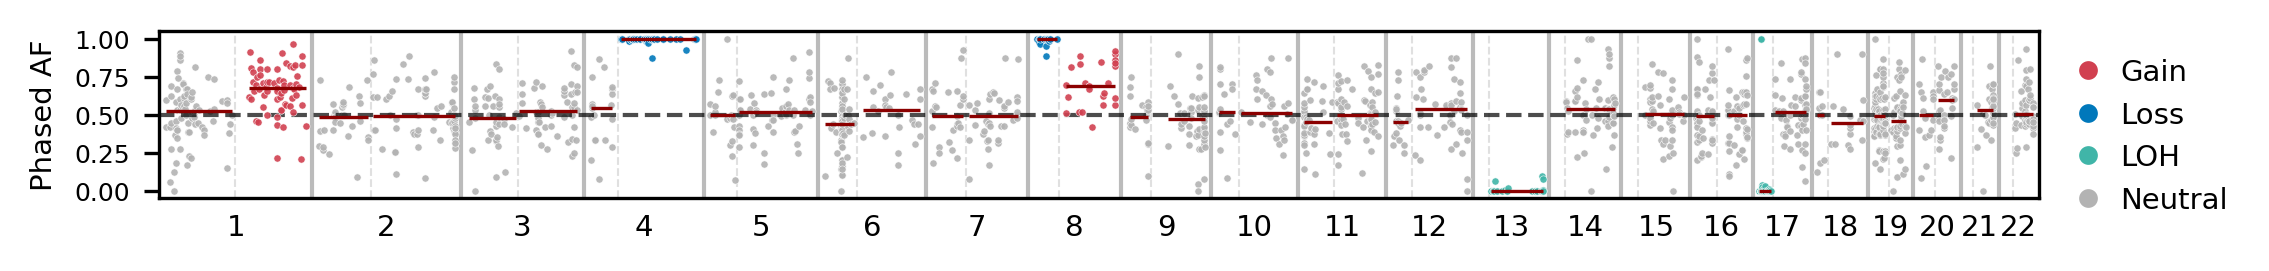

In [29]:
df = df_baf.loc[df_baf['group'] == 'stCNASim-rs_T'].copy()
print(df.shape)
fn = os.path.join(out_dir, sw_prefix + "baf-stCNASim-rs_T.png")
plot_baf(df, out_fn = fn, figsize = (7, 1))

(1559, 19)


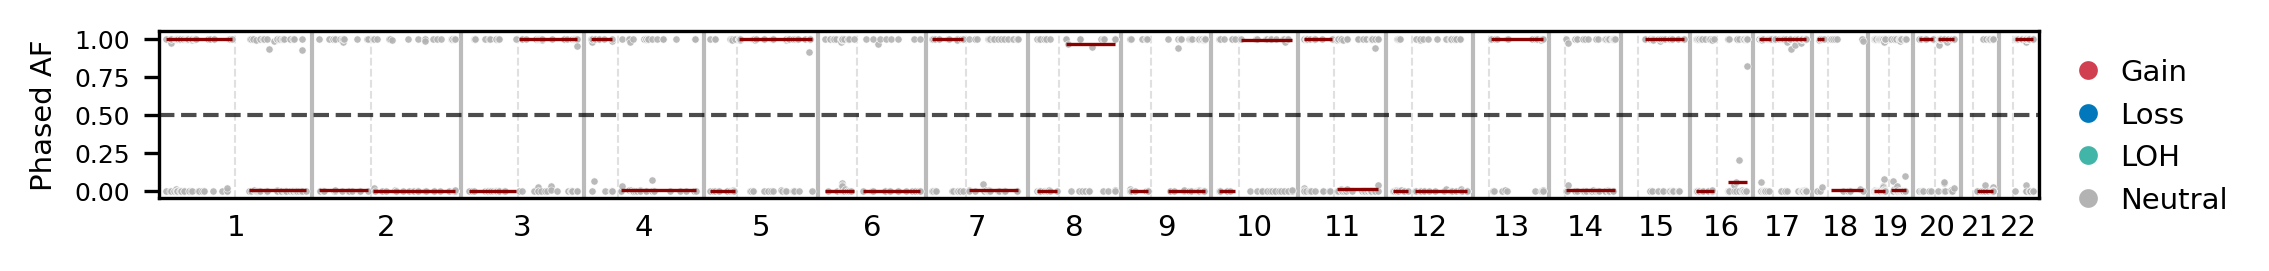

In [30]:
df = df_baf.loc[df_baf['group'] == 'scReadSim-cna_N'].copy()
print(df.shape)
df['snp_cna_type'] = 'Neutral'
fn = os.path.join(out_dir, sw_prefix + "baf-scReadSim-cna_N.png")
plot_baf(df, out_fn = fn, figsize = (7, 1))

(1556, 19)


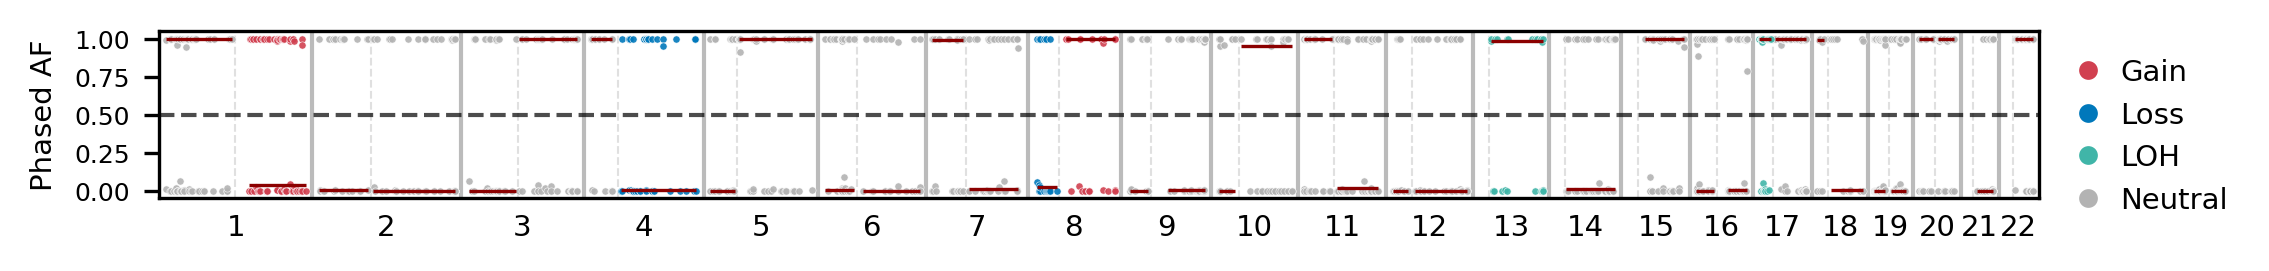

In [31]:
df = df_baf.loc[df_baf['group'] == 'scReadSim-cna_T'].copy()
print(df.shape)
fn = os.path.join(out_dir, sw_prefix + "baf-scReadSim-cna_T.png")
plot_baf(df, out_fn = fn, figsize = (7, 1))